**step 1 : Install Libraries**


In [ ]:
!pip -q install xgboost openpyxl

 **step 2 : Import Libraries**

In [ ]:
import os
import sqlite3
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


**step 3 : Data Load**

In [ ]:
import pandas as pd

FILE_NAME = "credit_risk_dataset.csv"

df = pd.read_csv(FILE_NAME)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**step 4 : Understand Data**

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows: 32581
Columns: 12

Column names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


** step 5 : Statistical Summary**

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


**step 6 : Check Missing Values**

In [17]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing[missing["Missing Count"] > 0]

,Missing Count,Missing %
person_emp_length,887,2.736303
loan_int_rate,3095,9.547754


Check Duplicate Rows

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 165


In [9]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (32416, 12)


Analyze Loan Default

In [10]:
print(df["loan_status"].value_counts())

loan_status
0    25327
1     7089
Name: count, dtype: int64


In [11]:
print(
    df["loan_status"]
    .value_counts(normalize=True) * 100
)

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


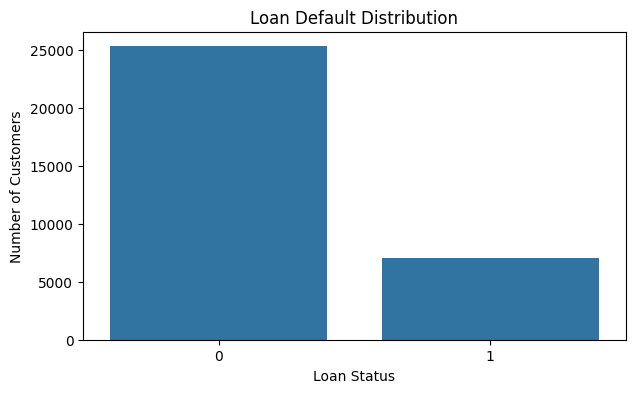

In [12]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")

plt.show()

Income vs Default

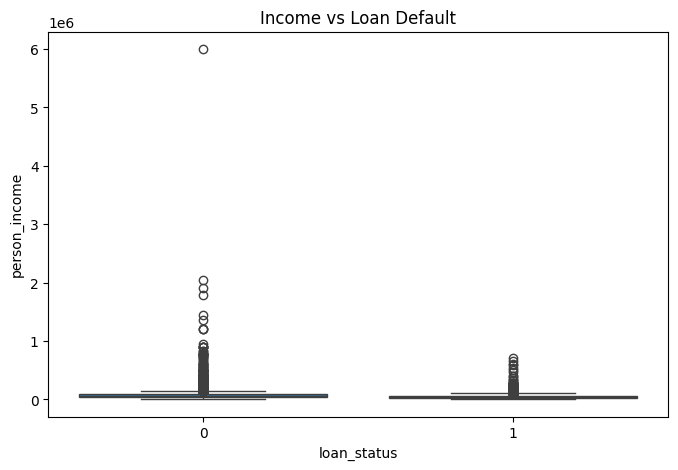

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="person_income"
)

plt.title("Income vs Loan Default")

plt.show()

Loan Amount vs Default

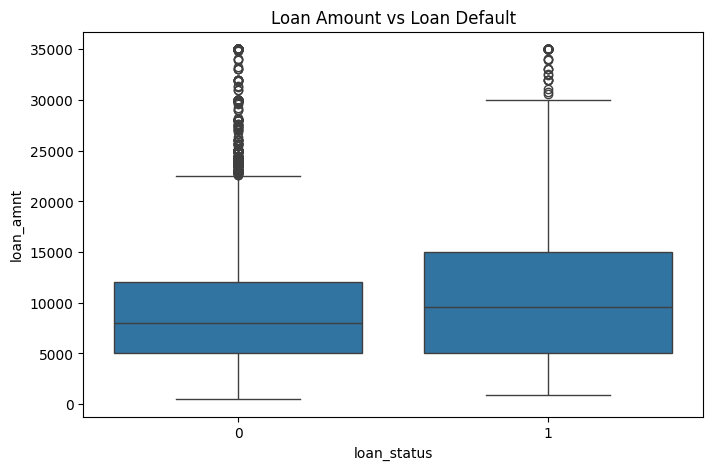

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_amnt"
)

plt.title("Loan Amount vs Loan Default")

plt.show()

Interest Rate vs Default

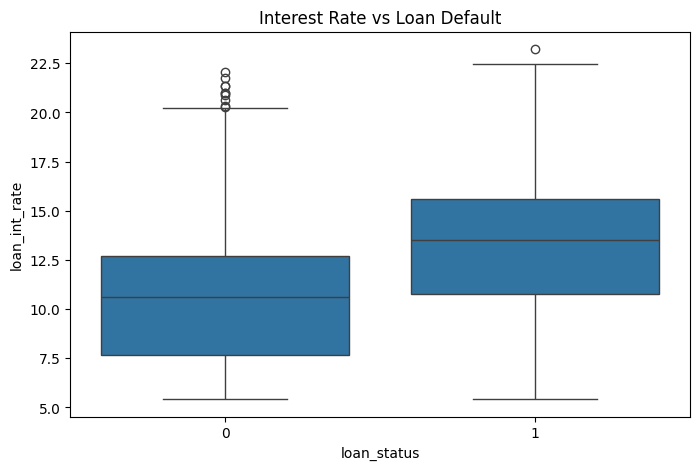

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="loan_status",
    y="loan_int_rate"
)

plt.title("Interest Rate vs Loan Default")

plt.show()

Loan Grade Analysis

In [18]:
grade_risk = (
    df.groupby("loan_grade")["loan_status"]
    .mean() * 100
)

print(grade_risk.sort_values(ascending=False))

loan_grade
G    98.437500
F    70.539419
E    64.485981
D    59.060773
C    20.751786
B    16.318475
A     9.959824
Name: loan_status, dtype: float64


Chart:

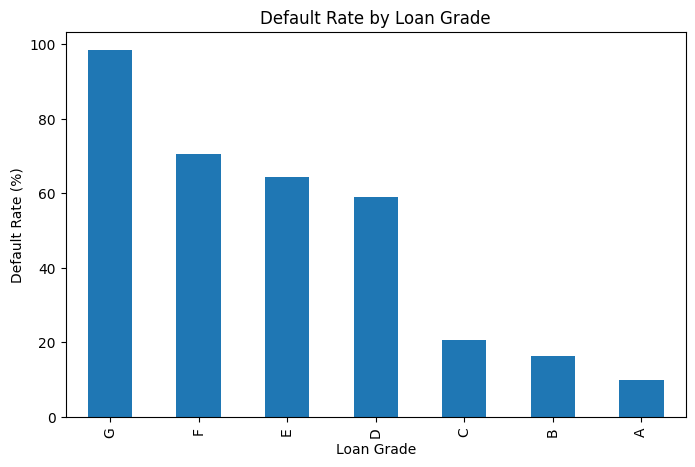

In [19]:
grade_risk.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default Rate by Loan Grade")
plt.ylabel("Default Rate (%)")
plt.xlabel("Loan Grade")

plt.show()

Loan Intent Analysis

In [20]:
intent_risk = (
    df.groupby("loan_intent")["loan_status"]
    .mean() * 100
)

print(intent_risk.sort_values(ascending=False))

loan_intent
DEBTCONSOLIDATION    28.676045
MEDICAL              26.762661
HOMEIMPROVEMENT      26.154702
PERSONAL             19.898145
EDUCATION            17.251599
VENTURE              14.853925
Name: loan_status, dtype: float64


Chart:

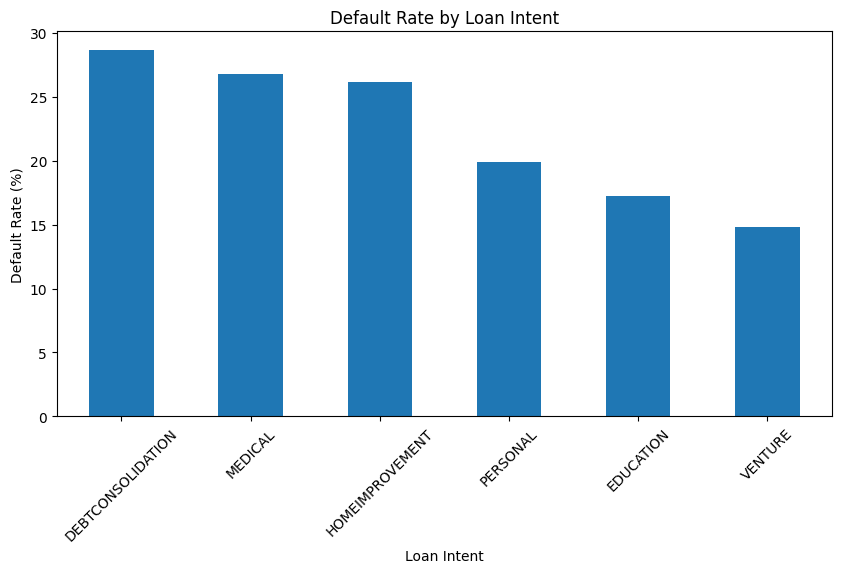

In [21]:
intent_risk.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Default Rate by Loan Intent")
plt.ylabel("Default Rate (%)")
plt.xlabel("Loan Intent")

plt.xticks(rotation=45)

plt.show()

Home Ownership Analysis

In [22]:
home_risk = (
    df.groupby("person_home_ownership")["loan_status"]
    .mean() * 100
)

print(home_risk.sort_values(ascending=False))

person_home_ownership
RENT        31.609476
OTHER       31.132075
MORTGAGE    12.618745
OWN          7.491221
Name: loan_status, dtype: float64


Previous Default Analysis

In [23]:
previous_default = (
    df.groupby("cb_person_default_on_file")["loan_status"]
    .mean() * 100
)

print(previous_default)

cb_person_default_on_file
N    18.432886
Y    37.870855
Name: loan_status, dtype: float64


Feature Engineering

Loan-to-income

In [24]:
df["loan_to_income"] = (
    df["loan_amnt"] /
    df["person_income"].replace(0, np.nan)
)

Monthly income

In [25]:
df["monthly_income"] = (
    df["person_income"] / 12
)

Monthly loan burden

In [26]:
df["loan_burden_monthly"] = (
    df["loan_amnt"] /
    df["monthly_income"].replace(0, np.nan)
)

Age group

In [27]:
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[0,25,35,50,100],
    labels=[
        "Young",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)

Employment group

In [28]:
df["employment_group"] = pd.cut(
    df["person_emp_length"],
    bins=[-np.inf,2,5,10,np.inf],
    labels=[
        "0-2 years",
        "3-5 years",
        "6-10 years",
        "10+ years"
    ]
)

Create High Loan Burden Flag

In [29]:
df["high_loan_burden_flag"] = (
    df["loan_percent_income"] >= 0.30
).astype(int)

In [30]:
df["high_loan_burden_flag"].value_counts()

,count
high_loan_burden_flag,
0,28149
1,4267


SQL Analysis

We're going to demonstrate SQL because PhonePe specifically asks for SQL.

Create SQLite database:

In [16]:
import sqlite3

conn = sqlite3.connect(":memory:")

sql_df = df.copy()

for col in sql_df.select_dtypes(
    include=["category"]
).columns:
    sql_df[col] = sql_df[col].astype(str)

sql_df.to_sql(
    "loan_data",
    conn,
    index=False,
    if_exists="replace"
)

print("SQL table created successfully.")

SQL table created successfully.


SQL Default Rate

In [31]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(loan_status) AS defaults,
    ROUND(AVG(loan_status) * 100, 2)
        AS default_rate_percent
FROM loan_data;
"""

pd.read_sql_query(query, conn)

,total_customers,defaults,default_rate_percent
0,32416,7089,21.87


SQL Risk by Grade

In [32]:
query = """
SELECT
    loan_grade,
    COUNT(*) AS customers,
    ROUND(
        AVG(loan_status) * 100,
        2
    ) AS default_rate_percent
FROM loan_data
GROUP BY loan_grade
ORDER BY default_rate_percent DESC;
"""

pd.read_sql_query(query, conn)

,loan_grade,customers,default_rate_percent
0,G,64,98.44
1,F,241,70.54
2,E,963,64.49
3,D,3620,59.06
4,C,6438,20.75
5,B,10387,16.32
6,A,10703,9.96


SQL Risk by Loan Intent

In [33]:
query = """
SELECT
    loan_intent,
    COUNT(*) AS customers,
    ROUND(
        AVG(loan_status) * 100,
        2
    ) AS default_rate_percent
FROM loan_data
GROUP BY loan_intent
ORDER BY default_rate_percent DESC;
"""

pd.read_sql_query(query, conn)

,loan_intent,customers,default_rate_percent
0,DEBTCONSOLIDATION,5189,28.68
1,MEDICAL,6042,26.76
2,HOMEIMPROVEMENT,3594,26.15
3,PERSONAL,5498,19.90
4,EDUCATION,6411,17.25
5,VENTURE,5682,14.85


Prepare Machine Learning Data

Separate features and target:

In [34]:
X = df.drop(
    columns=["loan_status"]
)

y = df["loan_status"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (25932, 17)
Testing: (6484, 17)


Preprocessing

In [36]:
numeric_features = X_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object","category"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_to_income', 'monthly_income', 'loan_burden_monthly', 'high_loan_burden_flag']
Categorical: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'age_group', 'employment_group']


Create preprocessing:

In [37]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

Decision Tree

In [38]:
dt_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42
        )
    )
])

dt_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'loan_to_income',
                                                   'monthly_income',
                                                   'loan_burden_monthly',
                                                   'high_loan_burden_flag']),
                                                 (...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file',
                                                   'age_group',
                                                   'employment_group'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20,
                                        random_state=42))])

Prediction:

In [39]:
dt_pred = dt_model.predict(X_test)

dt_prob = (
    dt_model.predict_proba(X_test)[:,1]
)

Evaluate Decision Tree

In [40]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        dt_prob
    )
)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      5066
           1       0.85      0.72      0.78      1418

    accuracy                           0.91      6484
   macro avg       0.89      0.84      0.86      6484
weighted avg       0.91      0.91      0.91      6484

ROC-AUC: 0.89511042392743


Random Forest

In [41]:
rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=250,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'loan_to_income',
                                                   'monthly_income',
                                                   'loan_burden_monthly',
                                                   'high_loan_burden_flag']),
                                                 (...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file',
                                                   'age_group',
                                                   'employment_group'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=5, n_estimators=250,
                                        n_jobs=-1, random_state=42))])

Prediction:

In [42]:
rf_pred = rf_model.predict(X_test)

rf_prob = (
    rf_model.predict_proba(X_test)[:,1]
)

Evaluation:

In [43]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5066
           1       0.88      0.75      0.81      1418

    accuracy                           0.92      6484
   macro avg       0.91      0.86      0.88      6484
weighted avg       0.92      0.92      0.92      6484

ROC-AUC: 0.9263288763219716


XGBoost

In [44]:
!pip -q install xgboost

Create model:

In [45]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

xgb_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )
    )
])

Train:

In [58]:
xgb_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'loan_to_income',
                                                   'monthly_income',
                                                   'loan_burden_monthly',
                                                   'high_loan_burden_flag']),
                                                 (...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Prediction:

In [59]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = (
    xgb_model.predict_proba(X_test)[:,1]
)

XGBoost Evaluation

In [60]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        xgb_prob
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5066
           1       0.86      0.79      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.90      0.88      0.89      6484
weighted avg       0.93      0.93      0.93      6484

ROC-AUC: 0.9513138838140495


In [61]:
# Get feature importances from the fitted XGBoost model
preprocessor_fitted = xgb_model.named_steps['preprocessor']
feature_names = preprocessor_fitted.get_feature_names_out()
importance = xgb_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

Compare Models

In [62]:
def evaluate_model(
    name,
    y_true,
    pred,
    prob
):
    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true, pred
        ),
        "Precision": precision_score(
            y_true, pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true, pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true, prob
        )
    }


results = pd.DataFrame([
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_pred,
        dt_prob
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    ),
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
])

results = results.sort_values(
    "ROC-AUC",
    ascending=False
)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.926434,0.858886,0.794076,0.825211,0.951314
1,Random Forest,0.923812,0.882450,0.751763,0.811881,0.926329
0,Decision Tree,0.910857,0.851171,0.717913,0.778883,0.895110


Confusion Matrix

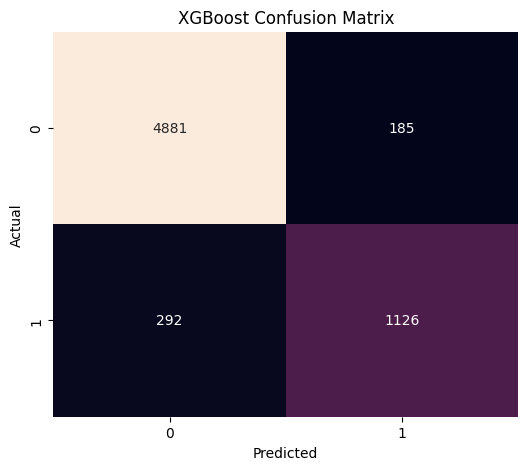

In [63]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Create Risk Probability

Now we're creating the most important business output.

In [64]:
predictions = X_test.copy()

predictions["actual_default"] = (
    y_test.values
)

predictions["default_probability"] = (
    xgb_prob
)

predictions["predicted_default"] = (
    xgb_pred
)

Low / Medium / High Risk

In [65]:
def risk_category(prob):

    if prob < 0.30:
        return "Low Risk"

    elif prob < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"


predictions["risk_category"] = (
    predictions[
        "default_probability"
    ].apply(risk_category)
)

In [ ]:
predictions[
    "risk_category"
].value_counts()

Risk Summary

In [66]:
risk_summary = (
    predictions
    .groupby("risk_category")
    .agg(
        customers=(
            "risk_category",
            "size"
        ),
        avg_default_probability=(
            "default_probability",
            "mean"
        ),
        actual_default_rate=(
            "actual_default",
            "mean"
        )
    )
    .reset_index()
)

risk_summary[
    "avg_default_probability"
] *= 100

risk_summary[
    "actual_default_rate"
] *= 100

risk_summary

,risk_category,customers,avg_default_probability,actual_default_rate
0,High Risk,1153,94.566330,94.015611
1,Low Risk,4387,10.527993,3.419193
2,Medium Risk,944,41.063057,19.491525


Risk Distribution Chart

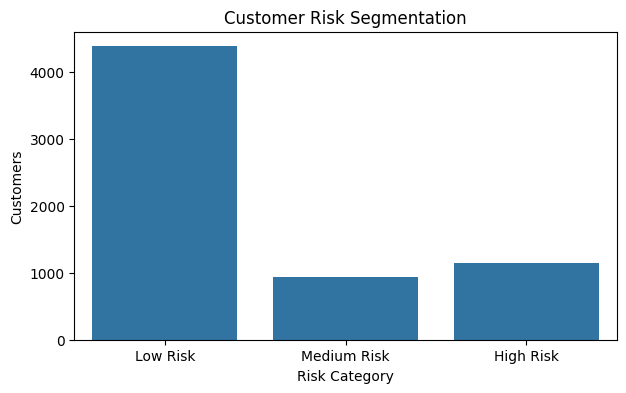

In [67]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=predictions,
    x="risk_category",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title(
    "Customer Risk Segmentation"
)

plt.xlabel("Risk Category")
plt.ylabel("Customers")

plt.show()

Export Results

Create dashboard dataset:

In [68]:
dashboard_df = predictions.copy()

dashboard_df.to_csv(
    "credit_risk_predictions.csv",
    index=False
)

risk_summary.to_csv(
    "risk_segment_summary.csv",
    index=False
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Files created successfully.")

Files created successfully.


Create Excel File

In [69]:
with pd.ExcelWriter(
    "credit_risk_analysis.xlsx",
    engine="openpyxl"
) as writer:

    dashboard_df.to_excel(
        writer,
        sheet_name="Predictions",
        index=False
    )

    risk_summary.to_excel(
        writer,
        sheet_name="Risk Summary",
        index=False
    )

    importance_df.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )

    results.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )

print(
    "credit_risk_analysis.xlsx created!"
)

credit_risk_analysis.xlsx created!


Download Files

In [70]:
from google.colab import files

files.download(
    "credit_risk_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
files.download(
    "credit_risk_analysis.xlsx"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
files.download(
    "risk_segment_summary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
files.download(
    "feature_importance.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
from google.colab import files

files.download(
    "model_comparison.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>